# Descripción del proyecto

Estás trabajando como analista para Zuber, una nueva empresa de viajes compartidos que se está lanzando en Chicago. Tu tarea es encontrar patrones en la información disponible. Quieres comprender las preferencias de los pasajeros y el impacto de los factores externos en los viajes.

Al trabajar con una base de datos, analizarás los datos de los competidores y probarás una hipótesis sobre el impacto del clima en la frecuencia de los viajes.

Descripción de los datos
Una base de datos con información sobre viajes en taxi en Chicago:

tabla neighborhoods: datos sobre los barrios de la ciudad

name: nombre del barrio
neighborhood_id: código del barrio
tabla cabs: datos sobre los taxis

cab_id: código del vehículo
vehicle_id: ID técnico del vehículo
company_name: la empresa propietaria del vehículo
tabla trips: datos sobre los viajes

trip_id: código del viaje
cab_id: código del vehículo que opera el viaje
start_ts: fecha y hora del inicio del viaje (tiempo redondeado a la hora)
end_ts: fecha y hora de finalización del viaje (tiempo redondeado a la hora)
duration_seconds: duración del viaje en segundos
distance_miles: distancia del viaje en millas
pickup_location_id: código del barrio de recogida
dropoff_location_id: código del barrio de finalización
tabla weather_records: datos sobre el clima

record_id: código del registro meteorológico
ts: fecha y hora del registro (tiempo redondeado a la hora)
temperature: temperatura cuando se tomó el registro
description: breve descripción de las condiciones meteorológicas, por ejemplo, "lluvia ligera" o "nubes dispersas"

# Paso 4. Análisis exploratorio de datos

## Librerías

In [60]:
# importar las librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats as st
import numpy as np

## Importar los archivos

In [61]:
# Leer los archivos
df_01 = pd.read_csv("datasets/moved_project_sql_result_01.csv")
df_04 = pd.read_csv("datasets/moved_project_sql_result_04.csv")

## Estudíar los datos

In [62]:
print(df_01.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None


In [63]:
print(df_01.tail())

                                 company_name  trips_amount
59               4053 - 40193 Adwar H. Nikola             7
60                    2733 - 74600 Benny Jona             7
61              5874 - 73628 Sergey Cab Corp.             5
62  2241 - 44667 - Felman Corp, Manuel Alonso             3
63                3556 - 36214 RC Andrews Cab             2


In [64]:
print(df_01.head(10))

                        company_name  trips_amount
0                          Flash Cab         19558
1          Taxi Affiliation Services         11422
2                   Medallion Leasin         10367
3                         Yellow Cab          9888
4    Taxi Affiliation Service Yellow          9299
5          Chicago Carriage Cab Corp          9181
6                       City Service          8448
7                           Sun Taxi          7701
8          Star North Management LLC          7455
9  Blue Ribbon Taxi Association Inc.          5953


In [65]:
# project_sql_result_04.csv
print(df_04.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
None


In [66]:
print(df_04.head(10))

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


Los datos estan correctos, no existe nulos ni otros detalles que puedan dificultar el análisis.

## Tipos de datos

In [67]:
print(df_01.dtypes)

company_name    object
trips_amount     int64
dtype: object


In [68]:
print(df_04.dtypes)

dropoff_location_name     object
average_trips            float64
dtype: object


Los tipos de datos de las columnas son los adecuadas

## Top 10 principales en terminos de finalización del recorrido

In [69]:
# Top 10 barrios
print(df_04.sort_values(by='average_trips', ascending=False).head(10))

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


Top 10 principales barrios en terminos de finalización

## Gráficos

### Empresa de taxis y número de viajes

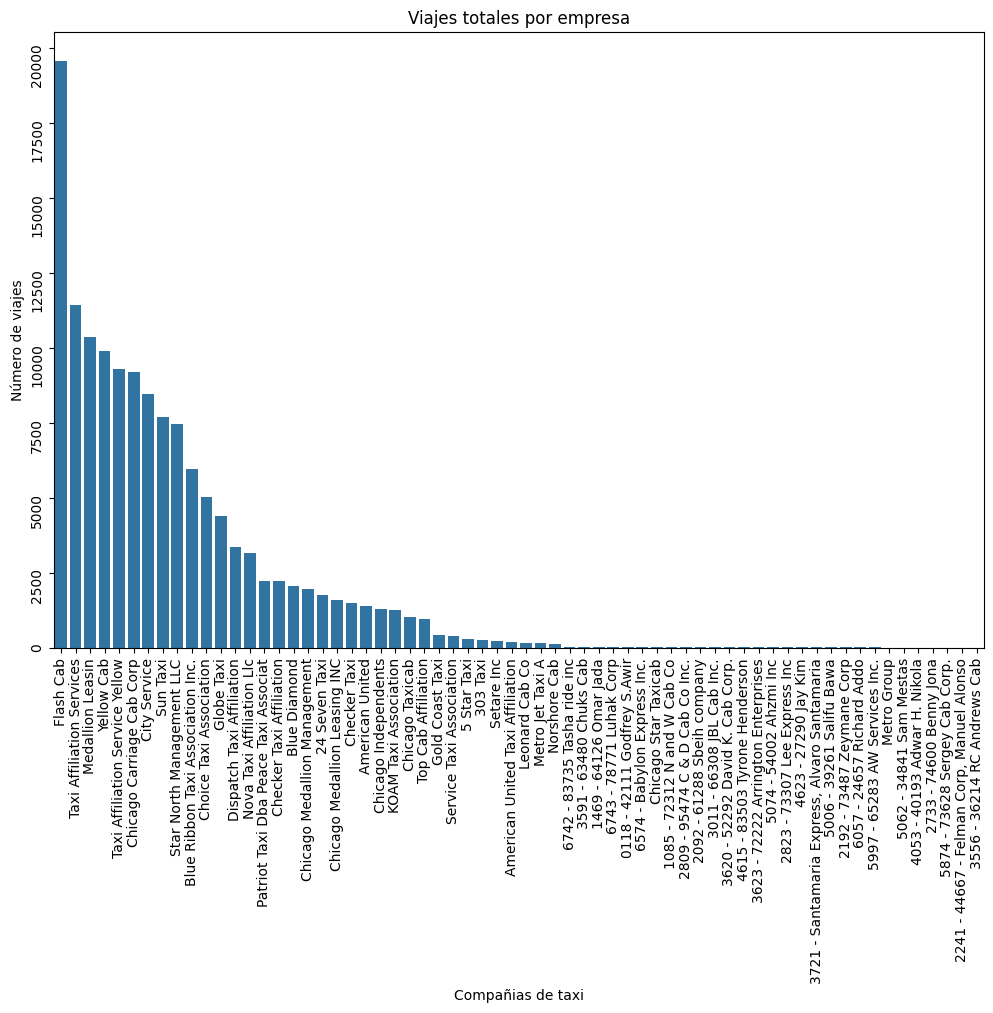

In [70]:
plt.figure(figsize=(12, 8))

sns.barplot(data=df_01, x='company_name', y='trips_amount')
plt.title('Viajes totales por empresa')
plt.xlabel('Compañias de taxi')
plt.ylabel('Número de viajes')
plt.tick_params(rotation=90)

plt.show()

De la grán mayoría de compañías de taxi son unas cuantas que dominan el mercado.
Observe también que se estan tomando en cuenta propietarios o licenciatarios los cuales se puede ver que sus número de viajes son muy bajos.

### Los 10 barrios principales por número de finalizaciones

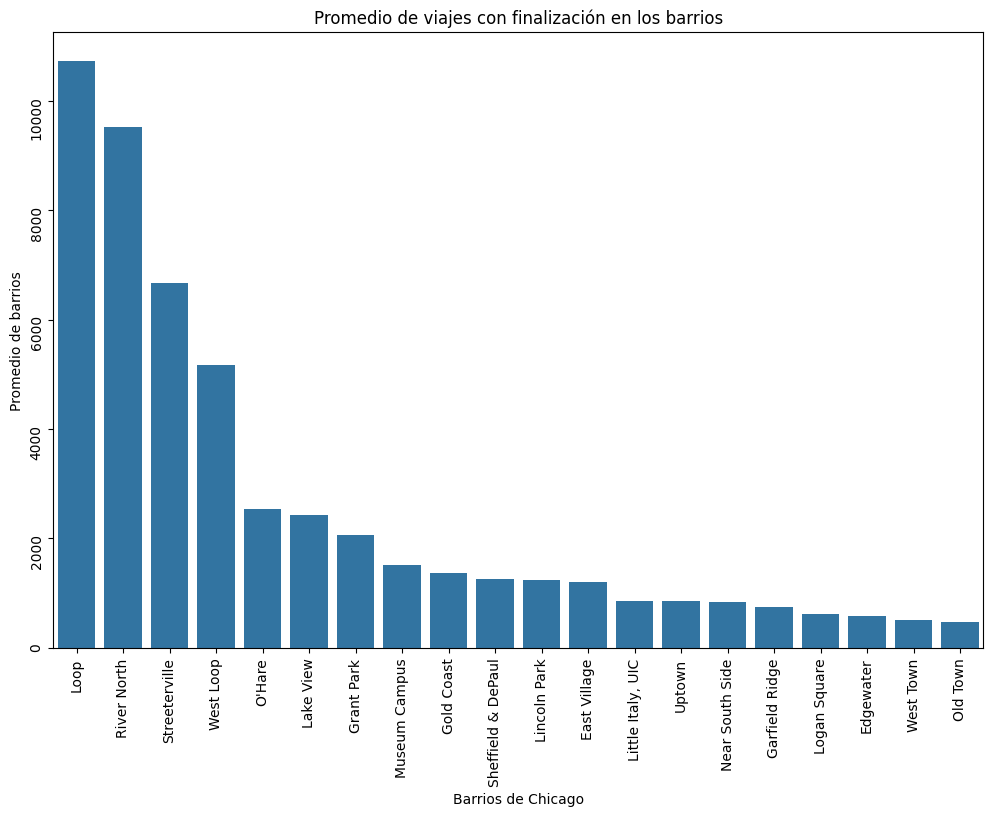

In [71]:
plt.figure(figsize=(12, 8))

sns.barplot(data=df_04.head(20), x='dropoff_location_name', y='average_trips')
plt.title('Promedio de viajes con finalización en los barrios')
plt.xlabel('Barrios de Chicago')
plt.ylabel('Promedio de barrios')
plt.tick_params(rotation=90)

plt.show()

Los barrios en los que finalizan sus viajes la mayoría de los taxis son barrios como Loop, River North y Streeterville. puede deverse a que las tiendas, centros turisticos y oficinas de Chicago estan situadas en estos barrios.


# Paso 5. Prueba de hipótesis

## Observar los datos

In [72]:
df_07 = pd.read_csv('datasets/moved_project_sql_result_07.csv')

In [73]:
print(df_07.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB
None


In [74]:
print(df_07.head(10))

              start_ts weather_conditions  duration_seconds
0  2017-11-25 16:00:00               Good            2410.0
1  2017-11-25 14:00:00               Good            1920.0
2  2017-11-25 12:00:00               Good            1543.0
3  2017-11-04 10:00:00               Good            2512.0
4  2017-11-11 07:00:00               Good            1440.0
5  2017-11-11 04:00:00               Good            1320.0
6  2017-11-04 16:00:00                Bad            2969.0
7  2017-11-18 11:00:00               Good            2280.0
8  2017-11-11 14:00:00               Good            2460.0
9  2017-11-11 12:00:00               Good            2040.0


In [75]:
print(df_07.size)

3204


## Prueba de hipótesis

"La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos"

In [76]:
# Separando los viajes

# Sábados lluviosos
good_df = df_07[df_07['weather_conditions'] == 'Good']
print(good_df.size)

# Sábados no lluviosos
bad_df = df_07[df_07['weather_conditions'] == 'Bad']
print(bad_df.size)

2664
540


In [77]:
# prueba de hipótesis

alpha = 0.05

results = st.ttest_ind(good_df['duration_seconds'], bad_df['duration_seconds'])

print(f'valor p:', results.pvalue)
print(f'valor p: {results.pvalue:.10f}')

if results.pvalue < alpha:
    print('Rechazamos la hipótesis nula')
else:
    print('No devemos rechazar la hipótesis nula')

valor p: 6.517970327099473e-12
valor p: 0.0000000000
Rechazamos la hipótesis nula


**Resultados de la prueba estadística:**

**Hipótesis planteadas:**

- H0: Las duraciones de los viajes cuando llueve y cuando cuando no llueve son iguales.
- H1: Las duraciones de los viajes cuando esta lluviendo y cuando no llueve son diferentes.

H0: Devido a que la hipótesis nula representa que no hay efecto o diferencia.

H1: Devido a que desafía la hipótesis nula y afirma que existe una diferencia significativa como para tratarse de una simple casualidad.


**Metodología aplicada:**

Prueba t de Student para muestra independientes con varianzas iguales.

Se aplicara esta prueba devido a que los viajes son evento independientes.


**Nivel de significancia seleccionad:**

0.05, devido a que es el estándar, balance.


**Decisión estadística:**

Como p-value < alpha, se puede reachazar H0.


**Conclusión:**

Entre los viajes los días lluviosos y los días no lluviosos si existe una diferencia significativa como para tratarse de simple casualidad. Por intuición podemos determinar que realmente los días lluviosos pueden traer dificultades en el trafico.